## Table of Contents
1. [Load Data and Initial Inspection](#1-load-data-and-initial-inspection)
2. [Data Quality and Missingness](#2-data-quality-and-missingness)
3. [Structural Cleaning](#3-structural-cleaning)
4. [Datatypes Conversion and Text Standardization](#4-datatypes-conversion-and-text-standardization)
5. [Feature Engineering](#5-feature-engineering)
6. [Exploratory Summary](#6-exploratory-summary)
7. [Export Cleaned Data](#7-export-cleaned-data)

## 1. Load Data and Initial Inspection

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/02_Parfumo_Perfumes.csv')

Throughout this notebook, the term fragrance is used to refer to all entries in the dataset, regardless of concentration or product type.


**Columns**  

| Column | Description |
|--------|-------------|
| Number | Internal Parfumo ID |
| Name | Perfume name |
| Brand | Fragrance house |
| Release_Year | Year first released |
| Concentration | EdT, EdP, Parfum, Cologne, After Shave, etc. |
| Rating_Value | Average user rating |
| Rating_Count | Number of user ratings |
| Main_Accords | Dominant scent families |
| Top / Middle / Base_Notes | Notes smelled over time |
| Perfumers | Creator name(s) |
| URL | Link to the full entry |

In [23]:
df.head(10)
df.shape # 59,325 rows and 13 columns
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 59325 entries, 0 to 59324
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Number         1420 non-null   str    
 1   Name           59324 non-null  str    
 2   Brand          59324 non-null  str    
 3   Release_Year   39009 non-null  float64
 4   Concentration  12483 non-null  str    
 5   Rating_Value   30046 non-null  float64
 6   Rating_Count   30046 non-null  float64
 7   Main_Accords   32225 non-null  str    
 8   Top_Notes      31139 non-null  str    
 9   Middle_Notes   31149 non-null  str    
 10  Base_Notes     31154 non-null  str    
 11  Perfumers      20544 non-null  str    
 12  URL            59325 non-null  str    
dtypes: float64(3), str(10)
memory usage: 16.3 MB
None





**Dataset Summary**  
Data contains 59,325 fragrances released between 1709 and 2024. It represents 1,451 unique brands.  

**Data Types**  
Only three quantitative variables: Release_Year, Rating_Value, and Rating_Count. Rest are string types.

**Missingsness**  
The dataset is highly sparse, with many optional metadata fields missing.



## 2. Data Quality and Missingness

In [24]:
df.isna().mean() * 100

Number           97.606405
Name              0.001686
Brand             0.001686
Release_Year     34.245259
Concentration    78.958281
Rating_Value     49.353561
Rating_Count     49.353561
Main_Accords     45.680573
Top_Notes        47.511167
Middle_Notes     47.494311
Base_Notes       47.485883
Perfumers        65.370417
URL               0.000000
dtype: float64

### Missing Data
- The dataset is highly sparse, with most missing values in descriptive fields such as notes, accords, perfumers, and concentration. 
- Core identifiers (Name, Brand, URL) are nearly complete.
- Missingness varies strongly across columns: Release_Year has ~34% missing values, while Concentration is missing in ~78% of cases. Rating data is available for roughly half of the entries.
- This pattern suggests systematic differences in data coverage rather than random missingness. 

➡ The full dataset is retained as a baseline, with column-specific subsets used where needed.


### Per-Brand Fragrance Count Is Capped by Scraping

`df["Brand"].value_counts()` shows most brands have 20 fragrances: is that a real catalog size, or an artifact of how this data was collected?  
 Checking the full distribution of fragrances-per-brand answers it.

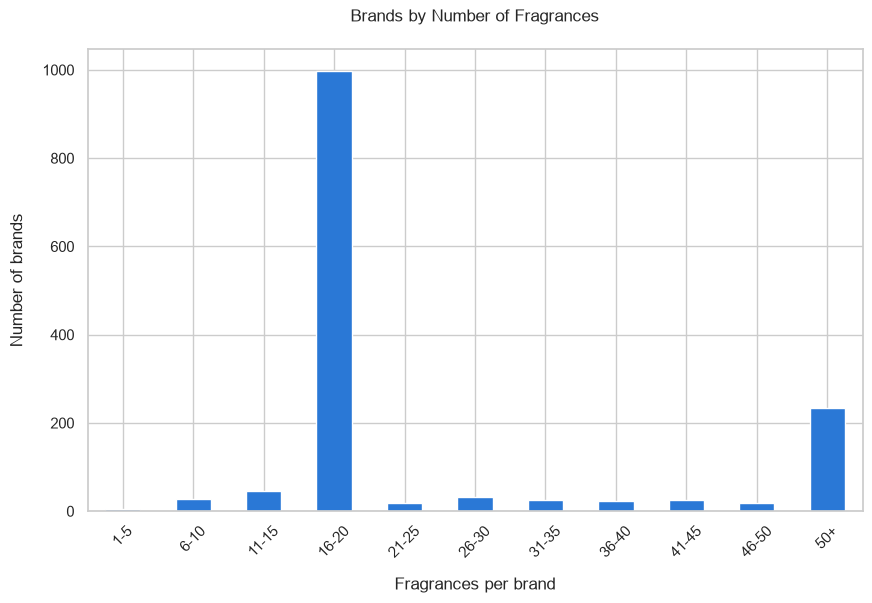

961 of 1451 brands (66%) have exactly 20 fragrances
Neighboring counts indicate it's not a normal distribution: 19 -> 9 brands, 21 -> 4 brands


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")

brand_counts = df["Brand"].value_counts()

bin_edges = list(range(0, 51, 5)) + [float('inf')]
bin_labels = [f'{bin_edges[i]+1}-{bin_edges[i+1]}' for i in range(len(bin_edges) - 2)] + ['50+']
bucketed = pd.cut(brand_counts, bins=bin_edges, labels=bin_labels)
brands_per_bucket = bucketed.value_counts().reindex(bin_labels)

ax = brands_per_bucket.plot(kind='bar', figsize=(10, 6), color="#2a78d6")
ax.tick_params(axis='x', rotation=45)
ax.set(xlabel='Fragrances per brand', ylabel='Number of brands',
       title='Brands by Number of Fragrances')
plt.show()

n_capped = (brand_counts == 20).sum()
print(f"{n_capped} of {len(brand_counts)} brands ({n_capped / len(brand_counts):.0%}) have exactly 20 fragrances")
print(f"Neighboring counts indicate it's not a normal distribution: 19 -> {(brand_counts == 19).sum()} brands, 21 -> {(brand_counts == 21).sum()} brands")

**The data**

There's a hard wall at exactly 20: roughly two-thirds of all 1,451 brands have precisely 20 fragrances, while the immediate neighbors (19 and 21) each have single digits. A genuine "typical brand size" wouldn't cliff-edge that sharply on one specific number. This marks an artificial cutoff.
Rating coverage confirms it's a truncation rather than a real catalog: fragrances from capped brands are notably less likely to have a `Rating_Value` than fragrances from uncapped brands. It could mean that the 20 that got kept aren't a brand's best-known or most-rated releases, but whatever came first in the source site's default catalog order.

**The meaning**

This points to a scraping artifact: parfumo paginates each brand's fragrance list, and whatever collected this dataset only fetched the first page (20 items) for the majority of brands, while a smaller set of major/popular houses — Avon (1,000), Zara (995) or Guerlain (586) — got fully paginated through.

 There's no way to recover the missing entries after the fact, so this is carried forward as a known limitation: **raw fragrance-count-per-brand is not a reliable measure of a brand's true catalog size for roughly three-quarters of brands**. It's fine to use for large, clearly-uncapped brands, but any claim about "how many fragrances a small brand has released" should be treated as a lower bound.

## 3. Structural Cleaning 

### Whitespace and Placeholder Check

In [26]:
text_cols = ['Name','Brand', 'Concentration', 'Main_Accords', 'Top_Notes', 'Middle_Notes', 'Base_Notes', 'Perfumers']

for col in text_cols:
    true_nan = df[col].isna()
    whitespace_only = df[col].str.strip() == ""
    placeholder = df[col].str.strip().str.lower().isin(['name?', 'none', 'nan', 'n/a', 'na', 'null', 'unknown', '-', '?'])
    total_weird = (true_nan | whitespace_only | placeholder).sum()
    print(f"{col}: NaN={true_nan.sum()}, whitespace-only={whitespace_only.sum()}, placeholder={placeholder.sum()}, total={total_weird}")

Name: NaN=1, whitespace-only=0, placeholder=6, total=7
Brand: NaN=1, whitespace-only=0, placeholder=0, total=1
Concentration: NaN=46842, whitespace-only=0, placeholder=0, total=46842
Main_Accords: NaN=27100, whitespace-only=0, placeholder=0, total=27100
Top_Notes: NaN=28186, whitespace-only=0, placeholder=0, total=28186
Middle_Notes: NaN=28176, whitespace-only=0, placeholder=0, total=28176
Base_Notes: NaN=28171, whitespace-only=0, placeholder=0, total=28171
Perfumers: NaN=38781, whitespace-only=0, placeholder=0, total=38781


A small number of rows contain no usable identifiers (e.g. missing Name and Brand) or placeholder names.

These entries are removed from the dataset as they cannot be reliably interpreted or linked to a fragrance.

In [27]:
# Drop rows with missing values in critical columns
df = df.dropna(subset=["Name", "Brand", "URL"], how="any")
df = df[df["Name"] != "NAME?"]

### Duplicate Rows

In [28]:
df.duplicated().sum()  # 9 rows are duplicated  completely
df[df.duplicated()]    # all 9 rows are empty placeholder data and can be dropped
df = df.drop_duplicates()

### Handling URL Duplicates (Edge Case: Frau Tonis Parfum)
There are 35 rows sharing duplicate URLs, restricted to a single brand. Manual inspection reveals that these duplicates stem from scraping/extraction errors.

Because automated deduplication (like `keep='first'`) would inject corrupted data into the analysis, and manual step-by-step verification is inefficient for this minor subset, all affected rows are strictly removed using `keep=False` to preserve data integrity.

In [29]:
df["URL"].duplicated().sum() # URL are not unique, there are 35 duplicates in the dataset
df[df["URL"].duplicated(keep=False)].sort_values("URL")

# drop all rows with duplicated URL values
df = df[~df["URL"].duplicated(keep=False)]
df["URL"].is_unique 

True

### Handling False Name Entries
The data has systematic data crawling mistakes, where fragrances with a year as their name (e.g. 1966) were falsely labeled as their brandname.  
Data from the URL was used to correctly relabel.

In [30]:
# Normalize brand for matching/comparisons
brand_lower = df['Brand'].str.strip().str.lower()

# Rows where Name is just a copy of Brand (real name got lost during scraping)
name_equals_brand = df['Name'].str.strip().str.lower() == brand_lower

# Brands that use "-" as a period (e.g. product codes like "6-0" -> "6.0")
is_zara = brand_lower.isin(['zara', 'tijon', "humphrey's handmade"])

# The real name lives in the last URL path segment
last_segment = df['URL'].str.rsplit('/', n=1).str[-1]

# Default rule: underscores and hyphens both become spaces
cleaned_name = last_segment.str.replace(r'[_-]', ' ', regex=True)

# Zara-style rule: underscores and hyphens both become periods
zara_cleaned = last_segment.str.replace(r'[_-]', '.', regex=True)

# Use the Zara-style cleaning only for the flagged brands, default cleaning otherwise
# then strip whitespace and collapse any double spaces left over (e.g. from "__")
cleaned_name = (
    cleaned_name
    .where(~is_zara, zara_cleaned)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# Preview before applying, to sanity-check the result
preview = df.loc[name_equals_brand, ['Name', 'Brand', 'URL']].assign(
    New_Name=cleaned_name.loc[name_equals_brand]
)
preview.sample(n=40)

# Apply the fix
df.loc[name_equals_brand, 'Name'] = cleaned_name.loc[name_equals_brand]


### Completeness Column

In [31]:
# Explicit column list (not all of df) so completeness reflects only the original data fields

COMPLETENESS_COLUMNS = [
    "Number", "Name", "Brand", "Release_Year", "Concentration",
    "Rating_Value", "Rating_Count", "Main_Accords", "Top_Notes",
    "Middle_Notes", "Base_Notes", "Perfumers", "URL",
]
df["completeness"] = (df[COMPLETENESS_COLUMNS].notna().mean(axis=1) * 100).round(1)

### Validating the Release_Year Outlier (1709)

`Release_Year` has a minimum of 1709 — checking whether this is a genuine historical entry or a scraping error before accepting it.

In [32]:
df[df["Release_Year"] == 1709][["Name", "Brand", "Release_Year", "URL"]]

,Name,Brand,Release_Year,URL
45345,Original Eau de Cologne,Johann Maria Farina gegenüber dem Jülichs-Platz,1709.0,https://www.parfumo.com/Perfumes/Johann_Maria_...


### Thoughts on dropping "Number" column
The Number column is an internal Parfumo identifier.  
Although it is frequently missing, it is retained as a supplementary reference field where available.  
It is not used as a primary key due to incomplete coverage.

URL values are not consistent identifiers in the original dataset due to extraction issues.  
To ensure internal consistency, all ambiguous URL entries were removed, resulting in a subset with unique URL values.  

## 4. Datatypes Conversion and Text Standardization

In [33]:
df["Release_Year"] = df["Release_Year"].astype("Int64")
df["Rating_Count"] = df["Rating_Count"].astype("Int64")
df.info()

<class 'pandas.DataFrame'>
Index: 59239 entries, 0 to 59318
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Number         1420 non-null   str    
 1   Name           59239 non-null  str    
 2   Brand          59239 non-null  str    
 3   Release_Year   38971 non-null  Int64  
 4   Concentration  12460 non-null  str    
 5   Rating_Value   30001 non-null  float64
 6   Rating_Count   30001 non-null  Int64  
 7   Main_Accords   32173 non-null  str    
 8   Top_Notes      31102 non-null  str    
 9   Middle_Notes   31112 non-null  str    
 10  Base_Notes     31117 non-null  str    
 11  Perfumers      20529 non-null  str    
 12  URL            59239 non-null  str    
 13  completeness   59239 non-null  float64
dtypes: Int64(2), float64(2), str(10)
memory usage: 17.3 MB


### Standardizing Multi-Value (comma-separated) Columns

`Main_Accords`, `Top_Notes`, `Middle_Notes`, `Base_Notes`, and `Perfumers` all store multiple values as comma-separated strings (e.g. `"Basil, Bergamot, Lemon, Orange"`).

Checks:
- **Whitespace**: ~69% of split tokens had leading/trailing spaces (from `", "` separators) — this breaks any exact-match comparison and needs stripping.
- **Mixed casing**: negligible — only 1 case-collision (`"sour milk"`) across ~2,600 unique Middle_Notes values, so no case normalization is applied (would risk mangling proper nouns in `Perfumers`).

Below: strip whitespace from every item in these columns.

In [34]:
def clean_multi_value(value, sep=","):
    """Strip whitespace from each item in a comma-separated string; leaves NaN as-is."""
    if pd.isna(value):
        return value
    items = [item.strip() for item in value.split(sep)]
    items = [item for item in items if item]
    return ", ".join(items)


MULTI_VALUE_COLUMNS = ["Main_Accords", "Top_Notes", "Middle_Notes", "Base_Notes", "Perfumers"]
for col in MULTI_VALUE_COLUMNS:
    df[col] = df[col].apply(clean_multi_value)

Confirmed genuine: this is "Original Eau de Cologne" by Johann Maria Farina, the original Kölnisch Wasser recipe first sold in 1709. No fix needed — the value is kept as-is.

### Cleaning Results

- URL links are now unique
- A new completeness column shows how complete a row is in %.
- 86 rows were removed due to duplicates or invalid records.
- Dataset still retains high missing values, I will use subsets where needed.

## 5. Feature Engineering

### Grouping Concentration into Standard Categories

`Concentration` has 412 unique values despite the column description implying a handful of standard types (EdT, EdP, Parfum, Cologne...). Inspecting the full list shows the diversity comes from three sources:
- **Multiple languages** for the same concept: French ("Après-Rasage", "Huile de Parfum"), Italian ("Profumo", "Dopobarba"), Spanish ("Colonia", "Pura Esencia").
- **Product form combined with scent type**: mist/spray/oil/gel/solid applied across body, hair, and cologne variants (e.g. "Cologne Mist", "Hair Perfume", "Perfume Stick").
- **Intensity modifiers stacked on a base type**: "Eau de Parfum Intense", "Eau de Parfum Concentrée", "Eau de Toilette Fraîche".

A single value-to-value mapping dict isn't practical at this scale, so a keyword-based classifier groups values into 10 categories, checked in priority order (product form — After Shave, Oil, Solid, Mist/Spray — before scent-concentration type — Eau de Parfum, Eau de Toilette, Eau de Cologne, Extrait/Parfum, Eau Fraiche — with a generic Perfume/Fragrance fallback).  
This groups 99.4% of non-null values; the remaining 79 rows (mostly ambiguous French "body water" phrases like "Eau pour le Corps") are left as `Other` rather than force-guessed.

In [35]:
import re
import unicodedata

def strip_accents(text):
    return "".join(c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c))

# Checked in order: product-form categories first, then scent-concentration types,
# so e.g. "Cologne Mist" lands in Mist/Spray rather than Eau de Cologne.
CONCENTRATION_RULES = [
    ("After Shave",       r"after.?shav|aftershav|rasage|barba|rasierwasser"),
    ("Oil",               r"\boil\b|huile|olio"),
    ("Solid",             r"solid|stick|compact|cushion|\bgel\b|cream|creme|crema|concret"),
    ("Mist/Spray",        r"mist|spray|brume|spritz|splash|bodyspray|body ?water|tonic|tonique|voile"),
    ("Eau de Parfum",     r"eau de parfum|eau de perfum|elixir de parfum|esprit de parfum"),
    ("Eau de Toilette",   r"eau de toilette|toilet water"),
    ("Eau de Cologne",    r"eau de cologne|\bcologne\b|colonia|acqua di colonia"),
    ("Extrait/Parfum",    r"\bparfum\b|extrait|extract|pure perfum|estratto|concentrat|profumo|essence|essenza|esencia|absolu|attar"),
    ("Eau Fraiche",       r"eau fraiche|fraicheur"),
    ("Perfume/Fragrance", r"perfume|fragrance|parfum|scent|senteur"),
]
COMPILED_RULES = [(label, re.compile(pattern)) for label, pattern in CONCENTRATION_RULES]

def classify_concentration(value):
    if pd.isna(value):
        return value
    normalized = strip_accents(value.lower())
    for label, pattern in COMPILED_RULES:
        if pattern.search(normalized):
            return label
    return "Other"

df["Concentration_Group"] = df["Concentration"].apply(classify_concentration)
df["Concentration_Group"].value_counts(dropna=False)

Concentration_Group
NaN                  46779
Eau de Parfum         2799
Eau de Toilette       2776
Extrait/Parfum        1626
After Shave           1415
Mist/Spray            1240
Solid                  683
Oil                    672
Eau de Cologne         652
Perfume/Fragrance      469
Other                   79
Eau Fraiche             49
Name: count, dtype: int64

### Brand Category: Designer vs. Niche

The designer vs. niche split is a common way of categorizing fragrance houses, useful for comparing how each side approaches production, marketing, and sales. The original data didn't include this distinction, so it was added manually.

- **Designer / fashion house** — a brand recognized primarily from clothing, accessories, or leather goods, where fragrance is a licensed line extension rather than the core business. E.g. Chanel, Dior, Yves Saint Laurent, Gucci, Prada, Hermès, Versace.
- **Niche / independent perfumery** — a brand whose entire business is fragrance (sometimes plus candles or home scents), with no clothing or leather-goods line. Covers both contemporary independents (Xerjoff, Amouage, Le Labo) and heritage perfumers (Guerlain, Creed) that were never fashion houses.

Rather than hand-picking niche brands individually, which is impractical across ~1,450 brands, **every brand not on the designer list defaults to niche**, since the industry's long tail really is mostly small independent perfumers. Exceptions are brands that fail the niche definition without being fashion houses either. They are marked `Unclassified` instead and include: 

- Cosmetics/skincare conglomerates (Lancôme, Estée Lauder)
- Celebrity-name licenses
- General retailers
- Direct-sale cosmetics companies
- Non-fragrance lifestyle licensors (Mercedes-Benz)

In [36]:
DESIGNER_HOUSES = {
    "Giorgio Armani", "Dior", "Hermès", "Yves Saint Laurent", "Tom Ford", "Chanel", "Zara",
    "Calvin Klein", "Bvlgari", "Prada", "Paco Rabanne", "Hugo Boss", "Mugler", "Dolce & Gabbana",
    "Gucci", "Givenchy", "Jean Paul Gaultier", "Jil Sander", "Comme des Garçons", "Louis Vuitton",
    "Cartier", "Joop!", "Burberry", "Versace", "Issey Miyake", "Kenzo", "Van Cleef & Arpels",
    "Valentino", "Narciso Rodriguez", "Maison Margiela", "Etro", "Montblanc", "Chloé",
    "Carolina Herrera", "Marc Jacobs", "Lacoste", "Bottega Veneta", "Rochas", "Cacharel",
    "Salvatore Ferragamo", "Trussardi", "Boucheron", "Loewe", "Diesel", "Lolita Lempicka",
    "Ralph Lauren", "DKNY / Donna Karan", "Laura Biagiotti", "John Varvatos", "Roberto Cavalli",
    "Dsquared²", "Zadig & Voltaire", "Karl Lagerfeld", "Azzaro", "Lanvin", "Viktor & Rolf",
    "Moschino", "Balmain", "Dunhill", "Aigner", "Abercrombie & Fitch", "Juicy Couture", "Cerruti",
    "Nina Ricci", "Tommy Hilfiger", "Celine", "Jimmy Choo", "Ermenegildo Zegna", "Fendi",
    "Oscar de la Renta", "Balenciaga", "Michael Kors", "Guess", "Benetton", "Coach", "Vera Wang",
    "Gianfranco Ferré", "Bogner", "Puma", "Iceberg", "Mauboussin", "Toni Gard", "Jacomo",
    "Courrèges", "Kenneth Cole", "Hollister", "Anna Sui", "Krizia", "Elie Saab", "Escada",
    "Ted Lapidus", "Victoria's Secret", "Mexx", "s.Oliver", "bugatti Fashion", "Grès",
    "Guy Laroche", "Costume National", "Otto Kern", "Jesus del Pozo", "Masakï Matsushïma", "Adidas",
    "Alexander McQueen", "Stella McCartney", "Vivienne Westwood", "Christian Louboutin",
    "Yohji Yamamoto", "Missoni", "Emanuel Ungaro", "Tiffany & Co.",
    "Chopard", "Agent Provocateur", "Banana Republic", "Bruno Banani", "Jean Patou",
    "Jean-Louis Scherrer", "La Perla", "Michalsky", "Tom Tailor",
    "Perry Ellis", "Paul Smith", "Ghost", "Halston", "Adolfo Dominguez", "Angel Schlesser",
    "Roccobarocco", "Fiorucci", "Baldessarini", "Worth", "Jacques Fath", "Jean-Charles Brosseau",
    "Georges Rech", "Léonard", "Bijan", "Alfred Sung", "Curve / Liz Claiborne", "Vince Camuto",
    "Ellen Tracy", "Gloria Vanderbilt", "Mila Schön", "Lancetti", "Blumarine", "Tory Burch",
    "Sonia Rykiel", "Byblos", "Molyneux", "Sean John", "Gian Marco Venturi", "Luciano Soprani",
    "Weil", "Montana", "Carven", "John Galliano", "Geoffrey Beene", "Kiton", "Enrico Coveri",
    "La Martina", "Liu•Jo", "Sergio Tacchini", "Springfield", "Massimo Dutti", "River Island",
    "American Eagle", "Urban Outfitters", "Aéropostale", "Old Navy", "GAP", "H&M", "Express",
    "Superdry", "MCM", "Ed Hardy", "Koton", "moussy / マウジー", "Victorinox", "Nike", "Fila",
    "Francesca's", "Claire's", "Ocean Pacific", "Mango", "Bershka", "Primark", "Police",
    "Betty Barclay", "Tous", "Replay", "French Connection / FCUK", "Tommy Bahama", "Nautica",
    "Mandarina Duck", "Korloff", "Elizabeth and James",
}

# Unclassified brands that clearly aren't a perfumery whose entire business is fragrance only
EXCLUDE_FROM_NICHE = {
    "Ariana Grande", "Avon", "Axe / Lynx", "Aēsop", "Bath & Body Works", "Britney Spears",
    "By Terry", "Christina Aguilera", "Clinique", "Coty", "David Beckham", "Davidoff",
    "Elizabeth Arden", "Elizabeth Taylor", "Estēe Lauder", "Frapin", "Jaguar", "Judith Williams",
    "Katy Perry", "Korres", "L'Erbolario", "L'Occitane en Provence", "Lalique", "Lancaster",
    "Lancôme", "Laura Mercier", "Lush / Cosmetics To Go", "Marbert", "Mercedes-Benz",
    "Molton Brown", "Naomi Campbell", "Oriflame", "Rammstein", "Rituals", "Salvador Dali",
    "Shiseido / 資生堂", "Sisley", "The Body Shop", "Yves Rocher",
    "Puig", "Helena Rubinstein", "Philosophy", "Paris Hilton", "Jennifer Lopez", "Banderas",
    "M. Asam", "Jafra", "Milton-Lloyd / Jean Yves Cosmetics", "California Perfume Company",
    "O Boticário", "Violette Market",
    "Ferrari", "Tonino Lamborghini", "Playboy", "James Bond 007", "Beyoncé", "Rihanna",
    "Shakira", "Cristiano Ronaldo", "Sarah Jessica Parker", "Jessica Simpson",
    "KKW Fragrance / Kim Kardashian", "Harajuku Lovers / Gwen Stefani", "Paloma Picasso",
    "Procter & Gamble", "Revlon / Charles Revson", "Clarins", "Biotherm", "Kiehl's", "Nuxe",
    "Juvena", "Missha", "Kosé / コーセー", "Pola / ポーラ", "Kanebo", "Decorté",
    "Orlane / Jean d'Albret", "Dermacol", "Perlier", "Gosh Cosmetics", "essence", "KIKO",
    "M∙A∙C", "General Cosmetics", "Dina Cosmetics", "Constance Carroll", "Alcina", "Farmasi",
    "Yanbal", "ésika", "Nutrimetics", "Vanda / Beauty Counselor", "Viviane Woodard",
    "Dorothy Gray", "Richard Hudnut", "Prince Matchabelli", "Jōvan", "Shulton",
    "Body Fantasies", "bodycology",
    "Sephora", "Boots", "Douglas", "Aldi / Hofer", "Lidl", "Mercadona",
}

df["Brand_Category"] = np.select(
    [df["Brand"].isin(DESIGNER_HOUSES), df["Brand"].isin(EXCLUDE_FROM_NICHE)],
    ["Designer", "Unclassified"], default="Niche",
)

brand_cat_counts = df.drop_duplicates("Brand")["Brand_Category"].value_counts()
print(f"Of {df['Brand'].nunique()} total brands: {brand_cat_counts.get('Designer', 0)} designer, "
      f"{brand_cat_counts.get('Niche', 0)} niche (default), "
      f"{brand_cat_counts.get('Unclassified', 0)} explicitly excluded")

Of 1451 total brands: 193 designer, 1152 niche (default), 106 explicitly excluded


## 6. Exploratory summary

In [37]:
print(df.shape) # 59,239 rows and 14 columns
print(df.describe(include='all') )

(59239, 16)
       Number    Name  Brand  Release_Year    Concentration  Rating_Value  \
count    1420   59239  59239       38971.0            12460  30001.000000   
unique    362   55153   1451          <NA>              412           NaN   
top       212  Chypre   Avon          <NA>  Eau de Toilette           NaN   
freq       71      37   1000          <NA>             2661           NaN   
mean      NaN     NaN    NaN   2006.267173              NaN      7.347768   
std       NaN     NaN    NaN      22.86725              NaN      0.933054   
min       NaN     NaN    NaN        1709.0              NaN      0.000000   
25%       NaN     NaN    NaN        2005.0              NaN      6.900000   
50%       NaN     NaN    NaN        2013.0              NaN      7.400000   
75%       NaN     NaN    NaN        2018.0              NaN      7.900000   
max       NaN     NaN    NaN        2024.0              NaN     10.000000   

        Rating_Count Main_Accords Top_Notes Middle_Notes Base_N

### Key Statistics
Median rating: 7.4  
Median rating count: 19  
Max rating count: 2,732  

➡ Ratings are skewed toward generally positive values.  
➡ Engagement varies strongly across fragrances, with a small subset receiving most ratings. 

### Release Year Distribution
Sanity check on how release years are spread out, grouped by decade.

In [38]:
decade = (df["Release_Year"] // 10 * 10).astype("Int64")
decade.value_counts().sort_index()

Release_Year
1700        1
1710        1
1740        1
1750        1
1760        1
1790        2
1800        2
1810        1
1820        4
1830        5
1840        6
1850        9
1860       17
1870       38
1880       46
1890      116
1900      226
1910      279
1920      378
1930      314
1940      262
1950      240
1960      389
1970      732
1980     1206
1990     2490
2000     7882
2010    17163
2020     7159
Name: count, dtype: Int64

### Top Brands and Main Accords
Most frequent values in the cleaned categorical fields, as a final sanity check before export.

In [39]:
print(df["Brand"].value_counts().head(5))
print()
print(df["Main_Accords"].value_counts().head(5))

Brand
Avon                 1000
Zara                  995
Victoria's Secret     995
Bath & Body Works     972
Guerlain              586
Name: count, dtype: int64

Main_Accords
Floral                                80
Floral, Fruity, Sweet                 62
Floral, Sweet                         53
Fruity, Sweet                         46
Green, Citrus, Spicy, Woody, Fresh    46
Name: count, dtype: int64


## 7. Export Cleaned Data

In [40]:
df.to_parquet("../data/cleaned_data.parquet", index=False)